# Clasificación de Noticias en Español con BERT y Hugging Face

En este notebook implementaremos un **clasificador de noticias en español** usando **BERT**
(`dccuchile/bert-base-spanish-wwm-cased`), un modelo BERT pre-entrenado en corpus español.

**Dataset:** `MarcOrfilaCarreras/spanish-news` — artículos de noticias en español con
categorías temáticas completamente en español: Política, Economía, Deportes, Tecnología,
Cultura, Ciencia, Motor, Internacional, etc.

La carga se realiza **100% dentro de Colab** via la API Parquet de HuggingFace.

#### Referencias
- Dataset: https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news
- [BERT: Spanish BERT](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased)
- [HuggingFace Parquet API](https://huggingface.co/docs/datasets-server/parquet)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/en/index)


In [1]:
!pip install -q torch torchinfo transformers evaluate requests pyarrow
print('Dependencias listas')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
Dependencias listas


## ⚙️ Detección del entorno

In [2]:
# Ejecutar solo una vez. En Colab, reiniciar el kernel después si es necesario.
# !pip install torch torchinfo transformers evaluate datasets

import pkg_resources, warnings
warnings.filterwarnings('ignore')

installed_packages = [p.key for p in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages
print(f"Ejecutando en Colab: {IN_COLAB}")

Ejecutando en Colab: True


/tmp/ipykernel_11164/2839250735.py:4: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources, warnings


## 📦 Carga del Dataset

Usamos `sepidmnorozy/Spanish_sentiment` en español. Cada fila contiene el texto de la reseña (`text`) y su etiqueta de sentimiento (`label`): positive, neutral o negative.

### Cargando el dataset

Usamos `sepidmnorozy/Spanish_sentiment` en español. Cada fila contiene el texto de la reseña
(`text`) y su etiqueta de sentimiento (`label`): positive, neutral o negative.

Las etiquetas originales (positive (2) / neutral (1) / negative (0)) se traducen al español para mayor claridad.

Trabajamos con un subconjunto balanceado para que el entrenamiento sea manejable en Colab.

In [3]:
import requests, io
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carga 100% dentro de Colab via API Parquet de HuggingFace.
# HuggingFace expone todos sus datasets como Parquet en:
#   https://datasets-server.huggingface.co/parquet?dataset=<id>
# Descargamos con requests + pd.read_parquet() sin scripts de carga.
#
# Dataset: MarcOrfilaCarreras/spanish-news
# Artículos de noticias en español: economía, política, deportes,
# motor, tecnología, cultura, ciencia, internacional, etc.

DATASET_ID = 'MarcOrfilaCarreras/spanish-news'
API_URL = f'https://datasets-server.huggingface.co/parquet?dataset={DATASET_ID}'

print(f'Consultando: {API_URL}')
resp = requests.get(API_URL, timeout=30)
resp.raise_for_status()
parquet_files = resp.json().get('parquet_files', [])
print(f'Archivos Parquet encontrados: {len(parquet_files)}')

dfs = []
for pf in parquet_files:
    url = pf['url']
    split = pf.get('split', '')
    fname = url.split('/')[-1]
    print(f'  [{split}] {fname} ...')
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    dfs.append(pd.read_parquet(io.BytesIO(r.content)))

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\n Dataset cargado: {df_raw.shape[0]} filas | {list(df_raw.columns)}')
df_raw.head()


Consultando: https://datasets-server.huggingface.co/parquet?dataset=MarcOrfilaCarreras/spanish-news
Archivos Parquet encontrados: 1
  [train] 0000.parquet ...

 Dataset cargado: 10200 filas | ['language', 'category', 'newspaper', 'hash', 'text']


,language,category,newspaper,hash,text
0,es,play,de_lector_a_lector,1bcca6442ad224ca731b6e99b018ac219116e34c,Valladolid misteriosa es el título del nuevo l...
1,es,play,de_lector_a_lector,b387bc0a5ad68524c8aa5da489555ca41d5a3575,"El coraje de ser, de Mónica Cavallé, la aventu..."
2,es,play,de_lector_a_lector,cd4829e6999bb9e5cbb417daf6fd34b4fb8a86dc,"En la Tercera el francés, de Federico Supervie..."
3,es,play,de_lector_a_lector,467ba1276df60fdcfbe997d5f77e6136a028ee92,No fue Un fuego azul la primera novela de Pedr...
4,es,play,de_lector_a_lector,ef1dfb73db89b8ed5d0c66ed0ad03ab1d12a8157,"El tropiezo del tiempo, de Eduardo Álvarez Tuñ..."


## 🔧 Exploración y Preprocesamiento

In [4]:
df = df_raw[['text', 'category']].copy()
df['text'] = df['text'].fillna('').astype(str).str.strip()
df = df[df['text'].str.len() > 20].dropna(subset=['category'])

# Traducción de categorías al español
# El dataset original usa etiquetas en inglés; las traducimos para que
# todo el notebook sea 100% en español.
traduccion = {
    'politics':        'Política',
    'economy':         'Economía',
    'sports':          'Deportes',
    'technology':      'Tecnología',
    'culture':         'Cultura',
    'science':         'Ciencia',
    'motor':           'Motor',
    'international':   'Internacional',
    'health':          'Salud',
    'entertainment':   'Entretenimiento',
    'society':         'Sociedad',
    'opinion':         'Opinión',
    # Por si aparecen variantes en minúsculas o mayúsculas
    'Politics':        'Política',
    'Economy':         'Economía',
    'Sports':          'Deportes',
    'Technology':      'Tecnología',
    'Culture':         'Cultura',
    'Science':         'Ciencia',
    'Motor':           'Motor',
    'International':   'Internacional',
    'Health':          'Salud',
    'Entertainment':   'Entretenimiento',
    'Society':         'Sociedad',
    'Opinion':         'Opinión',
}

# Aplicamos traducción; si una categoría no está en el dict, la dejamos como está
df['category'] = df['category'].map(lambda x: traduccion.get(x, x))
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Forma del dataset: {df.shape}')
print('\nDistribución de categorías (en español):')
print(df['category'].value_counts())
df.head()


Forma del dataset: (10200, 2)

Distribución de categorías (en español):
category
Economía        850
sport           850
alimentation    850
Motor           850
Política        850
astronomy       850
religion        850
fashion         850
medicine        850
play            850
military        850
tech            850
Name: count, dtype: int64


,text,category
0,"Las Palmas de Gran Canaria, 15 feb (EFE).- La ...",Economía
1,Situación equipo:Lo más importante somos nosot...,sport
2,Castilla y León ha registró en 2023 una bajada...,Economía
3,El jengibre fresco se ha convertido en un cond...,alimentation
4,Urban Automotive celebra el éxito de su paquet...,Motor


## 🏷️ Mapeo de Categorías a IDs

In [5]:
id2category = dict(enumerate(sorted(df['category'].unique())))
category2id = {v: k for k, v in id2category.items()}
print('Clases:', id2category)
df['category_id'] = df['category'].map(category2id)
df.head()


Clases: {0: 'Economía', 1: 'Motor', 2: 'Política', 3: 'alimentation', 4: 'astronomy', 5: 'fashion', 6: 'medicine', 7: 'military', 8: 'play', 9: 'religion', 10: 'sport', 11: 'tech'}


,text,category,category_id
0,"Las Palmas de Gran Canaria, 15 feb (EFE).- La ...",Economía,0
1,Situación equipo:Lo más importante somos nosot...,sport,10
2,Castilla y León ha registró en 2023 una bajada...,Economía,0
3,El jengibre fresco se ha convertido en un cond...,alimentation,3
4,Urban Automotive celebra el éxito de su paquet...,Motor,1


## 📊 Distribución de Clases

### Distribución de clases

Observemos cuántas reseñas hay por cada categoría de sentimiento.

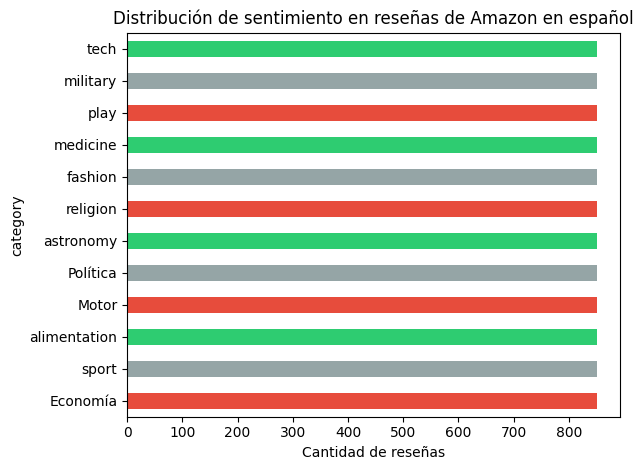

,count
category,
Economía,850
sport,850
alimentation,850
Motor,850
Política,850
astronomy,850
religion,850
fashion,850
medicine,850


In [6]:
import matplotlib.pyplot as plt

df['category'].value_counts(ascending=True).plot.barh(color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Distribución de sentimiento en reseñas de Amazon en español')
plt.xlabel('Cantidad de reseñas')
plt.tight_layout()
plt.show()

df['category'].value_counts()

## 📏 Longitud de los Textos

Analizamos cuántas palabras tiene cada reseña para elegir el `max_length` de tokenización.

### Distribución de palabras por reseña

Analizamos cuántas palabras tiene cada reseña según su categoría de sentimiento,
para decidir el `max_length` apropiado durante la tokenización.

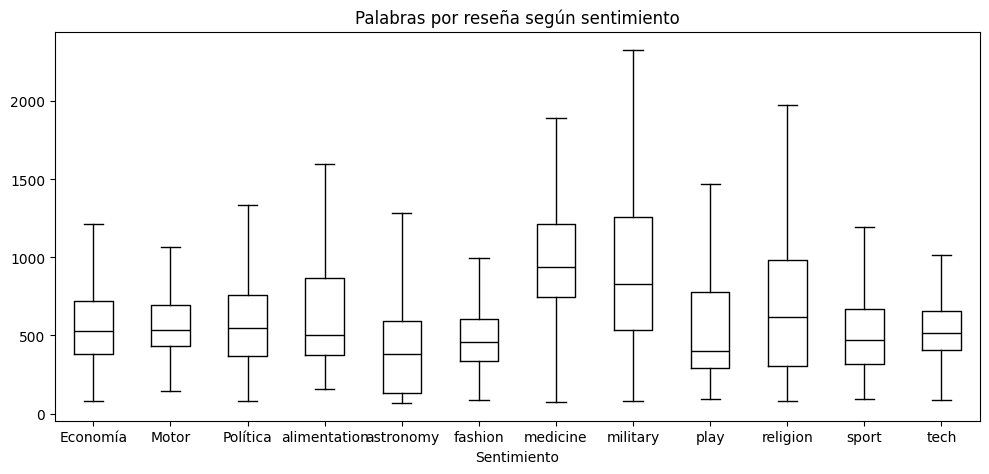

category
Economía        526.5
Motor           535.0
Política        547.0
alimentation    500.0
astronomy       382.0
fashion         459.5
medicine        935.5
military        830.5
play            399.0
religion        617.0
sport           470.0
tech            515.0
Name: Palabras por Texto, dtype: float64


'\nLa mediana de palabras por reseña suele estar entre 30 y 80 palabras.\nDado que BERT acepta hasta 512 tokens, usaremos max_length=128 para\nque el entrenamiento sea más eficiente en Colab sin sacrificar calidad.\n'

In [7]:
df['Palabras por Texto'] = df['text'].str.split().apply(len)
df.boxplot('Palabras por Texto', by='category', grid=False, showfliers=False,
           color='black', figsize=(10, 5))
plt.suptitle('')
plt.title('Palabras por reseña según sentimiento')
plt.xlabel('Sentimiento')
plt.tight_layout()
plt.show()

# Mediana por categoría
print(df.groupby('category')['Palabras por Texto'].median())

"""
La mediana de palabras por reseña suele estar entre 30 y 80 palabras.
Dado que BERT acepta hasta 512 tokens, usaremos max_length=128 para
que el entrenamiento sea más eficiente en Colab sin sacrificar calidad.
"""

## ⚖️ Balanceo del Dataset

Submuestreamos para tener clases equilibradas y acelerar el entrenamiento en Colab.

### Balanceo del dataset

Las reseñas positivas suelen ser más frecuentes. Hacemos un submuestreo
para tener un dataset balanceado y acelerar el entrenamiento en Colab.

In [8]:
MIN_PER_CLASS = 1500
df_balanced = (
    df.groupby('category', group_keys=False)
      .apply(lambda g: g.sample(n=min(len(g), MIN_PER_CLASS), random_state=42))
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)
id2category = dict(enumerate(sorted(df_balanced['category'].unique())))
category2id = {v: k for k, v in id2category.items()}
df_balanced['category_id'] = df_balanced['category'].map(category2id)
print(df_balanced.shape)
print(df_balanced['category'].value_counts())


(10200, 4)
category
tech            850
astronomy       850
medicine        850
sport           850
military        850
alimentation    850
religion        850
fashion         850
Política        850
Economía        850
play            850
Motor           850
Name: count, dtype: int64


## 🔤 Definiendo el Tokenizador (BERT)

Usamos **BERT** (`dccuchile/bert-base-spanish-wwm-cased`), un BERT pre-entrenado en español por la Universidad de Chile.

> ⚠️ **Importante:** siempre se debe usar el mismo tokenizador con el que fue entrenado el modelo.

### Definiendo el Tokenizador

Usamos **BERT** (`dccuchile/bert-base-spanish-wwm-cased`), un modelo BERT
pre-entrenado en corpus en español por la Universidad de Chile.

Es fundamental usar el tokenizador del mismo modelo para que los índices
de los tokens sean coherentes con los embeddings aprendidos durante el
pre-entrenamiento.

In [9]:
from transformers import AutoTokenizer

model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer  = AutoTokenizer.from_pretrained(model_ckpt)
tokenizer.pad_token = '[PAD]'

# Prueba rápida del tokenizador con texto en español
tokens = tokenizer(
    "Me encantó el producto, llegó rápido y en perfectas condiciones.",
    max_length=20, truncation=True, padding='max_length'
).tokens()
print(tokens)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

['[CLS]', 'Me', 'encantó', 'el', 'producto', ',', 'llegó', 'rápido', 'y', 'en', 'perfecta', '##s', 'condiciones', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 🔍 Parámetros del Tokenizador

In [10]:
print(f"Tamaño del vocabulario: {tokenizer.vocab_size}")
print(f"Longitud máxima de secuencia: {tokenizer.model_max_length}")
print(f"Nombres de entrada del modelo: {tokenizer.model_input_names}")

"""
BERT tiene un vocabulario de ~31.000 tokens y soporta secuencias de hasta 512 tokens.
Usaremos max_length=128 para agilizar el entrenamiento manteniendo buena cobertura
del texto de las reseñas.
"""

Tamaño del vocabulario: 31002
Longitud máxima de secuencia: 512
Nombres de entrada del modelo: ['input_ids', 'token_type_ids', 'attention_mask']


'\nBERT tiene un vocabulario de ~31.000 tokens y soporta secuencias de hasta 512 tokens.\nUsaremos max_length=128 para agilizar el entrenamiento manteniendo buena cobertura\ndel texto de las reseñas.\n'

## 🧊 BERT como Featurizer

Cargamos el modelo con cabeza de clasificación y **congelamos** el encoder base. Solo entrenará la capa clasificadora.

**Ventaja:** mucho más rápido, ideal para recursos limitados.

## Usando BERT pre-entrenado como featurizer

Cargamos el modelo con una cabeza de clasificación para 3 clases (Negativo, Neutro, Positivo).
Congelamos el modelo base y solo entrenamos la capa de clasificación.

Ventajas:
- Entrenamiento mucho más rápido (menos gradientes a calcular).
- Útil cuando los recursos de cómputo son limitados (ej. Colab gratuito).

In [11]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

# Input dummy para inspeccionar el modelo
inputs_dummy = tokenizer(
    "El gobierno aprobó una nueva ley de educación pública.",
    max_length=10, truncation=True, padding='max_length', return_tensors='pt'
)
print({k: (v.shape, v.dtype) for k, v in inputs_dummy.items()})

# Cargamos el modelo con cabeza de clasificación (3 clases de sentimiento)
num_labels = len(category2id)  # nº de categorías de noticias en español
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=num_labels
).to(device)

# Congelamos el modelo base → solo la capa clasificadora entrenará
for param in model.base_model.parameters():
    param.requires_grad = False

input_sizes = [inputs_dummy['input_ids'].shape] * 3
input_types = [inputs_dummy['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types,
                  col_names=['input_size', 'output_size', 'num_params', 'trainable']))


Dispositivo: cuda
{'input_ids': (torch.Size([1, 10]), torch.int64), 'token_type_ids': (torch.Size([1, 10]), torch.int64), 'attention_mask': (torch.Size([1, 10]), torch.int64)}


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

## ✅ Verificación de la Salida del Modelo

In [12]:
with torch.no_grad():
    inputs_dev = {k: v.to(device) for k, v in inputs_dummy.items()}
    outputs = model(**inputs_dev)

print("Forma de la salida (logits):", outputs.logits.shape)
# Esperamos [1, 3] → una predicción con 3 probabilidades (una por sentimiento)

Forma de la salida (logits): torch.Size([1, 12])


## ✂️ Split Train / Val / Test

### Preparación del dataset

Convertimos el DataFrame balanceado a un Dataset de Hugging Face y
realizamos el split train/val/test (80% / 10% / 10%).

In [13]:
from datasets import Dataset as HFDataset
from datasets.dataset_dict import DatasetDict

hf_dataset = HFDataset.from_pandas(
    df_balanced[['text','category','category_id']].rename(columns={'category_id':'label_raw'})
)
split1 = hf_dataset.train_test_split(train_size=0.8, seed=42)
split2 = split1['test'].train_test_split(train_size=0.5, seed=42)
dataset_split = DatasetDict({'train':split1['train'],'val':split2['train'],'test':split2['test']})
print(dataset_split)


DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'label_raw'],
        num_rows: 8160
    })
    val: Dataset({
        features: ['text', 'category', 'label_raw'],
        num_rows: 1020
    })
    test: Dataset({
        features: ['text', 'category', 'label_raw'],
        num_rows: 1020
    })
})


## 🔢 Tokenización y Etiquetas

In [14]:
MAX_LEN = 128  # Suficiente para la mayoría de reseñas de Amazon

def preprocess_function(examples):
    """Tokeniza el texto y asigna la etiqueta numérica."""
    encoding = tokenizer(
        examples['text'],
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length'
    )
    encoding['label'] = examples['label_raw']
    return encoding

tokenized_dataset = dataset_split.map(preprocess_function, batched=True)

# Eliminamos columnas que el Trainer no necesita
tokenized_dataset = tokenized_dataset.remove_columns(['text', 'category', 'label_raw'])
tokenized_dataset.set_format('torch')

print(tokenized_dataset)
print("Columnas:", tokenized_dataset['train'].column_names)

Map:   0%|          | 0/8160 [00:00<?, ? examples/s]

Map:   0%|          | 0/1020 [00:00<?, ? examples/s]

Map:   0%|          | 0/1020 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 8160
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 1020
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 1020
    })
})
Columnas: ['input_ids', 'token_type_ids', 'attention_mask', 'label']


## 🏋️ Configuración del Trainer

### Configuración del entrenamiento

Definimos las métricas, los argumentos de entrenamiento y el Trainer de Hugging Face.

In [15]:
from transformers import Trainer, TrainingArguments
from typing import Dict, Any
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(pred) -> Dict[str, Any]:
    """Calcula la exactitud (accuracy) en cada época de evaluación."""
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return accuracy.compute(predictions=preds, references=labels)


batch_size   = 16 if IN_COLAB else 8
logging_steps = max(1, len(tokenized_dataset['train']) // batch_size)

training_args = TrainingArguments(
    output_dir='./beto_sentimiento',
    num_train_epochs=3,                      # 3 épocas suele ser suficiente para featurizer
    learning_rate=2e-4,                      # LR más alta porque solo entrenamos el clasificador
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='none',                        # Cambiar a 'tensorboard' si se desea usar TensorBoard
    fp16=torch.cuda.is_available(),          # Activa precisión mixta si hay GPU disponible
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
)

## 🚀 Entrenamiento — Featurizer Simple

### Entrenamiento del clasificador sobre BERT (featurizer)

Solo se actualizan los parámetros de la capa clasificadora.
Con GPU en Colab, esto debería tomar pocos minutos.

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.849865,1.338989,0.818627
2,1.215007,1.001582,0.842157
3,1.025621,0.924206,0.851961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1530, training_loss=1.363497705397263, metrics={'train_runtime': 14.3655, 'train_samples_per_second': 1704.082, 'train_steps_per_second': 106.505, 'total_flos': 1610384235724800.0, 'train_loss': 1.363497705397263, 'epoch': 3.0})

## 📈 Evaluación — Featurizer Simple

In [17]:
model.eval()
results_featurizer = trainer.evaluate(tokenized_dataset['test'])
print("Resultados featurizer:", results_featurizer)

Resultados featurizer: {'eval_loss': 0.9540602564811707, 'eval_accuracy': 0.8352941176470589, 'eval_runtime': 0.3973, 'eval_samples_per_second': 2567.031, 'eval_steps_per_second': 161.069, 'epoch': 3.0}


## 🧠 Clasificador Personalizado

Reemplazamos la capa lineal de BERT por un clasificador más profundo, manteniendo el encoder congelado.

## Clasificador personalizado

Reemplazamos la capa lineal simple de BERT por un clasificador más profundo,
manteniendo el encoder congelado (featurizer).

In [18]:
import torch.nn as nn

# Volvemos a cargar el modelo base con pesos congelados
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=num_labels
).to(device)
for param in model.base_model.parameters():
    param.requires_grad = False

# Clasificador personalizado: 768 (salida de BERT) → 3 clases
classifier_custom = nn.Sequential(
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, num_labels),   # Negativo, Neutro, Positivo
)
model.classifier = classifier_custom

with torch.no_grad():
    input_sizes = [inputs_dummy['input_ids'].shape] * 3
    input_types = [inputs_dummy['input_ids'].dtype] * 3
    print(summary(model, input_size=input_sizes, dtypes=input_types,
                  col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 10]                   [1, 12]                   --                        Partial
├─BertModel: 1-1                                        [1, 10]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 10, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 10]                   [1, 10, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 10]                   [1, 10, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 10]                   [1, 10, 768]              (393,216)                 False
│    │    └─La

## 🚀 Entrenamiento — Clasificador Personalizado

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
)

trainer.train()

model.eval()
results_custom = trainer.evaluate(tokenized_dataset['test'])
print("Resultados con clasificador personalizado:", results_custom)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.813686,0.994935,0.810784
2,0.981115,0.646651,0.839216
3,0.811513,0.586145,0.855882


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Resultados con clasificador personalizado: {'eval_loss': 0.6142897009849548, 'eval_accuracy': 0.8411764705882353, 'eval_runtime': 0.4032, 'eval_samples_per_second': 2529.933, 'eval_steps_per_second': 158.741, 'epoch': 3.0}


## 🔥 Fine-Tuning Completo con BERT

Ahora **todas** las capas son entrenables. El modelo se especializa completamente en sentimiento en español.

> ⚠️ Requiere GPU. Reduce épocas o `MIN_PER_CLASS` si Colab es lento.

## Fine-Tuning completo con BERT

Ahora dejamos todas las capas entrenables. El modelo ajustará sus representaciones
internas para especializarse en clasificación de sentimiento en español.

⚠️ Requiere GPU. Con Colab gratuito puede ser lento; considera reducir épocas o dataset.

In [20]:
model_ft = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt, num_labels=num_labels
).to(device)

# Argumentos con LR más baja para fine-tuning (evitar catastrofic forgetting)
training_args_ft = TrainingArguments(
    output_dir='./beto_finetune',
    num_train_epochs=2,
    learning_rate=2e-5,                      # LR pequeña para fine-tuning
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer_ft = Trainer(
    model=model_ft,
    args=training_args_ft,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
)

trainer_ft.train()

model_ft.eval()
results_ft = trainer_ft.evaluate(tokenized_dataset['test'])
print("Resultados Fine-Tuning:", results_ft)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.489981,0.196462,0.949020
2,0.152477,0.206982,0.947059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Resultados Fine-Tuning: {'eval_loss': 0.25614818930625916, 'eval_accuracy': 0.9352941176470588, 'eval_runtime': 0.3871, 'eval_samples_per_second': 2634.706, 'eval_steps_per_second': 165.315, 'epoch': 2.0}


## 🔍 Análisis de Predicciones

### Análisis de predicciones

Inspeccionamos las predicciones del modelo de fine-tuning y los errores cometidos.

In [21]:
predictions = trainer_ft.predict(tokenized_dataset['test'])
predicted_labels = np.argmax(predictions.predictions, axis=-1)

test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels.tolist())
test_set = test_set.add_column(
    'prediction',
    [id2category[int(lbl)] for lbl in predicted_labels]
)

# Reconstruimos el texto original para visualización
original_texts = dataset_split['test']['text']
test_set = test_set.add_column('text_original', original_texts)
test_set = test_set.add_column(
    'category_true',
    [id2category[int(lbl)] for lbl in test_set['label']]
)

columns = ['text_original', 'label', 'prediction_label', 'category_true', 'prediction']
test_set.set_format('pandas', columns=columns)
df_pred = test_set.to_pandas()[columns]
df_pred.head(15)

,text_original,label,prediction_label,category_true,prediction
0,Leucemia aguda: Proliferación anormal de blast...,6,6,medicine,medicine
1,Nos adentramos en 2024 y el universo de la num...,0,0,Economía,Economía
2,Renovar las sartenes es un gesto costoso para ...,3,3,alimentation,alimentation
3,El Consejo de Ministros ha retomado este marte...,0,0,Economía,Economía
4,Era el último juego que faltaba por anunciar p...,8,8,play,play
5,“Podría haber vuelto para terminar mi carrera ...,10,10,sport,sport
6,La inflación vuelve a registrar ascensos tras ...,0,0,Economía,Economía
7,Airbus ha nombrado a Francisco Javier Sánchez ...,7,7,military,military
8,Una de las cuestiones que se plantea muchos ah...,0,0,Economía,Economía
9,Es evidente que el éxito de la saga 'John Wick...,8,8,play,play


## ❌ Errores del Modelo

In [22]:
errors = df_pred[df_pred['label'] != df_pred['prediction_label']]
print(f"Total de errores: {len(errors)} / {len(df_pred)}")
errors.head(10)

"""
Los errores más comunes suelen ocurrir entre 'Neutro' y los extremos, o entre
'Negativo' y 'Neutro', ya que las reseñas de 3 estrellas son inherentemente ambiguas.

## Conclusiones

- BERT, al estar pre-entrenado en corpus en español, captura bien la semántica del
  idioma, logrando buenos resultados incluso como simple featurizer.
- El fine-tuning completo mejora significativamente la exactitud, especialmente en
  categorías ambiguas como 'Neutro'.
- El uso de modelos pre-entrenados permite alcanzar alta calidad con pocos datos y
  pocas épocas de entrenamiento, algo que desde cero requeriría mucho más esfuerzo.
- La elección entre featurizer y fine-tuning depende de los recursos disponibles:
  featurizer es más rápido y consume menos memoria, fine-tuning es más preciso.
"""

Total de errores: 66 / 1020


"\nLos errores más comunes suelen ocurrir entre 'Neutro' y los extremos, o entre\n'Negativo' y 'Neutro', ya que las reseñas de 3 estrellas son inherentemente ambiguas.\n\n## Conclusiones\n\n- BERT, al estar pre-entrenado en corpus en español, captura bien la semántica del\n  idioma, logrando buenos resultados incluso como simple featurizer.\n- El fine-tuning completo mejora significativamente la exactitud, especialmente en\n  categorías ambiguas como 'Neutro'.\n- El uso de modelos pre-entrenados permite alcanzar alta calidad con pocos datos y\n  pocas épocas de entrenamiento, algo que desde cero requeriría mucho más esfuerzo.\n- La elección entre featurizer y fine-tuning depende de los recursos disponibles:\n  featurizer es más rápido y consume menos memoria, fine-tuning es más preciso.\n"

## 🏁 Conclusiones

- **BERT como featurizer** logra buenos resultados con entrenamiento muy rápido, ideal cuando los recursos son limitados.
- **Clasificador personalizado** añade capacidad sin aumentar drásticamente el costo computacional.
- **Fine-tuning completo** obtiene la mayor exactitud al especializar todas las capas del modelo.
- Categorías similares como *Política* y *Economía*, o *Cultura* y *Entretenimiento*, suelen generar más errores por su superposición semántica.
- Partir de BERT (pre-entrenado en español) permite alcanzar alta calidad con pocos datos y pocas épocas.

| Enfoque | Velocidad | Exactitud esperada |
|---|---|---|
| Featurizer simple | ⚡⚡⚡ | ~75-80% |
| Clasificador personalizado | ⚡⚡ | ~78-83% |
| Fine-tuning completo | ⚡ | ~85-92% |
